# Use 'Explode' for Skill Count

In [113]:
# install libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
import ast

# sort by date
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# convert job_skills to list
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

In [114]:
# now lets use explode method
df_explode = df.explode('job_skills').copy()

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

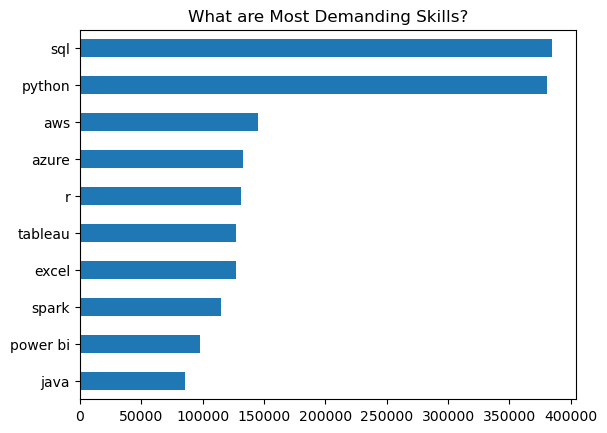

In [116]:
# now we want value counts
df_explode['job_skills'].value_counts().head(10)

# now lets try to plot this
df_explode['job_skills'].value_counts().head(10).sort_values(ascending=True).plot(kind='barh')

# formatting
plt.xlabel('')
plt.ylabel('')
plt.title('What are Most Demanding Skills?')
plt.legend().remove()
plt.show()




In [117]:
# lets try to include job title short in the dataframe
skills_count = df_explode.groupby(['job_title_short','job_skills']).size()
df_skills_count = skills_count.reset_index(name='skill_count')

In [118]:
df_skills_count = df_skills_count.sort_values(by='skill_count',ascending=False)

In [119]:
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


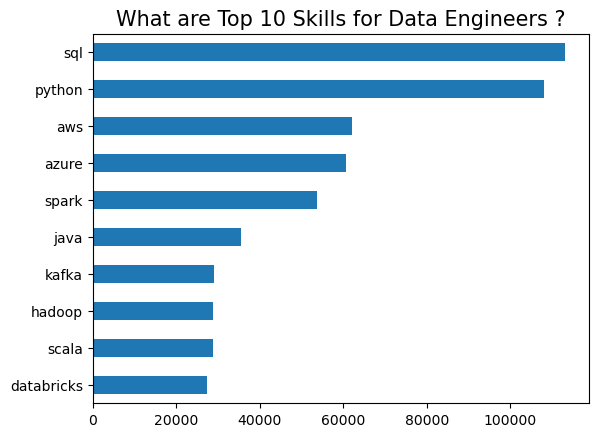

[None, None, None, None, None, None]

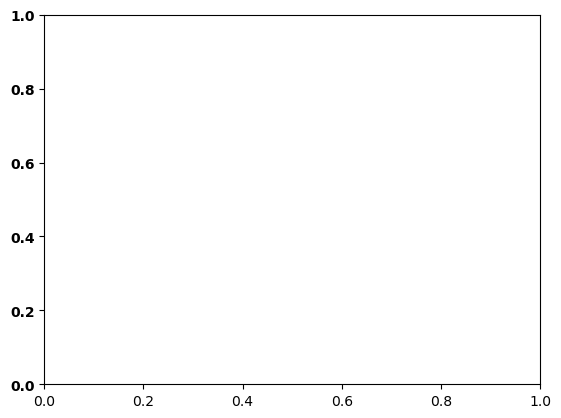

In [ ]:
# You can put the required job title and number of top skills Below
job_title = 'Data Engineer'
top_skills = 10


df_skill_final = df_skills_count[df_skills_count['job_title_short']==job_title].head(top_skills).sort_values(by='skill_count',ascending=True)

# now lets plot this 
df_skill_final.plot(kind='barh',x='job_skills',y='skill_count')

# now lets create the fromatting
plt.xlabel('')
plt.ylabel('')
plt.title(f'What are Top {top_skills} Skills for {job_title}s ?',fontsize=15)
plt.legend().remove()
plt.show()